# ⚛ Data Wrangling or Munging

****1. Import Data ▶****

In [1]:

import pandas as pd

file_path = '/content/DHV Dataset_Indian_Economy_&_GDP_Growth.xlsx'
df = pd.read_excel(file_path)

print("Data imported successfully:")
print(df.head())


Data imported successfully:
   Year  GDP (Nominal)  GDP (Real)   GDP growth (annual %)   \
0  1971          35.58        67.4                 1.642930   
1  1972          36.06        71.5                -0.553301   
2  1973          38.32        85.5                 3.295521   
3  1974          38.47        99.5                 1.185336   
4  1975          41.57        98.5                 9.149912   

   Agriculture Contribution (% of GDP)  Industry Contribution (% of GDP)  \
0                                34.58                             26.47   
1                                34.44                             26.48   
2                                34.06                             25.77   
3                                34.23                             25.85   
4                                35.26                             25.19   

   Services Contribution (% of GDP)  Inflation CPI  Unemployment Rate (%)  \
0                             43.32       5.324841         

****2. Data Cleaning ▶****

2.1] Find Missing Values and Remove Them

In [2]:

print("Missing values before removal:")
print(df.isnull().sum())
df.dropna(inplace=True)
print("Missing values after removal:")
print(df.isnull().sum())


Missing values before removal:
Year                                            0
GDP (Nominal)                                   0
GDP (Real)                                      0
 GDP growth (annual %)                          0
Agriculture Contribution (% of GDP)             0
Industry Contribution (% of GDP)                0
Services Contribution (% of GDP)                0
Inflation CPI                                   0
Unemployment Rate (%)                           0
Exports (% of GDP)                              0
 Imports  (% of GDP)                            0
FDI Inflows (USD)                               0
Fiscal Deficit (% of GDP)                       0
Public Debt (% of GDP)                          0
Repo Rate (%)                                   0
Foreign Exchange Reserves (MILLION USD)         0
Population Growth Rate (annual %)               0
Oil rents (% of GDP)                            2
Government Revenues (% of GDP)                  0
Household Consumpti

2.2] Identify Duplicate Values and Remove Them

In [3]:

print("Duplicate rows before removal:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate rows after removal:", df.duplicated().sum())


Duplicate rows before removal: 0
Duplicate rows after removal: 0


2.3] Find Outliers

   a) Using the IQR Method

In [4]:

numeric_df = df.select_dtypes(include=['number'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

non_outliers_mask = ~((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)

df_no_outliers = df[non_outliers_mask]

print("Data after removing outliers:")
print(df_no_outliers.head())


Data after removing outliers:
   Year  GDP (Nominal)  GDP (Real)   GDP growth (annual %)   \
1  1972          36.06        71.5                -0.553301   
4  1975          41.57        98.5                 9.149912   
5  1976          42.86       102.7                 1.663104   
6  1977          44.86       121.5                 7.254765   
7  1978          45.62       137.3                 5.712532   

   Agriculture Contribution (% of GDP)  Industry Contribution (% of GDP)  \
1                                34.44                             26.48   
4                                35.26                             25.19   
5                                36.35                             24.55   
6                                35.91                             24.40   
7                                35.37                             24.31   

   Services Contribution (% of GDP)  Inflation CPI  Unemployment Rate (%)  \
1                             43.74      10.839600       

b) Using the Z-score method

In [5]:

numeric_df = df.select_dtypes(include=['number'])

mean = numeric_df.mean()
std_dev = numeric_df.std()

z_scores = (numeric_df - mean) / std_dev

threshold = 3

outliers = (z_scores.abs() > threshold)

df_no_outliers = df[(~outliers).all(axis=1)]

print("Data after removing outliers using manual Z-score method:")
print(df_no_outliers.head())


Data after removing outliers using manual Z-score method:
   Year  GDP (Nominal)  GDP (Real)   GDP growth (annual %)   \
1  1972          36.06        71.5                -0.553301   
2  1973          38.32        85.5                 3.295521   
3  1974          38.47        99.5                 1.185336   
4  1975          41.57        98.5                 9.149912   
5  1976          42.86       102.7                 1.663104   

   Agriculture Contribution (% of GDP)  Industry Contribution (% of GDP)  \
1                                34.44                             26.48   
2                                34.06                             25.77   
3                                34.23                             25.85   
4                                35.26                             25.19   
5                                36.35                             24.55   

   Services Contribution (% of GDP)  Inflation CPI  Unemployment Rate (%)  \
1                            

****3. Data Transformation ▶****

3.1] Min - Max Normalization

In [6]:

numeric_df = df.select_dtypes(include=['number'])

min_values = numeric_df.min()
max_values = numeric_df.max()

df_min_max_normalized = (numeric_df - min_values) / (max_values - min_values)

df_normalized = df.copy()
df_normalized[numeric_df.columns] = df_min_max_normalized

print("Data after manual Min-Max Normalization:")
print(df_normalized.head())


Data after manual Min-Max Normalization:
   Year  GDP (Nominal)  GDP (Real)   GDP growth (annual %)   \
0  0.00       0.000000    0.000000                 0.479764   
1  0.02       0.000166    0.001321                 0.337772   
2  0.04       0.000947    0.005834                 0.586608   
3  0.06       0.000998    0.010346                 0.450179   
4  0.08       0.002069    0.010024                 0.965108   

   Agriculture Contribution (% of GDP)  Industry Contribution (% of GDP)  \
0                             0.919325                          0.916473   
1                             0.912944                          0.918794   
2                             0.895624                          0.754060   
3                             0.903373                          0.772622   
4                             0.950319                          0.619490   

   Services Contribution (% of GDP)  Inflation CPI  Unemployment Rate (%)  \
0                          0.000000       0.35

3.2]  Z - Score Normalization

In [7]:

numeric_df = df.select_dtypes(include=['number'])

mean = numeric_df.mean()
std_dev = numeric_df.std()

df_zscore_normalized = (numeric_df - mean) / std_dev

df_normalized = df.copy()
df_normalized[numeric_df.columns] = df_zscore_normalized

print("Data after manual Z-score Normalization:")
print(df_normalized.head())



Data after manual Z-score Normalization:
       Year  GDP (Nominal)  GDP (Real)   GDP growth (annual %)   \
0 -1.681682      -0.650171   -0.860059                -1.144004   
1 -1.614415      -0.649656   -0.855490                -1.825473   
2 -1.547147      -0.647229   -0.839886                -0.631220   
3 -1.479880      -0.647068   -0.824282                -1.285991   
4 -1.412613      -0.643739   -0.825397                 1.185342   

   Agriculture Contribution (% of GDP)  Industry Contribution (% of GDP)  \
0                             1.280396                          1.090829   
1                             1.260906                          1.104183   
2                             1.208007                          0.156057   
3                             1.231673                          0.262888   
4                             1.375058                         -0.618468   

   Services Contribution (% of GDP)  Inflation CPI  Unemployment Rate (%)  \
0                     

#  ⚛ Trends in Indian Economy and GDP Growth: A Comprehensive Overview

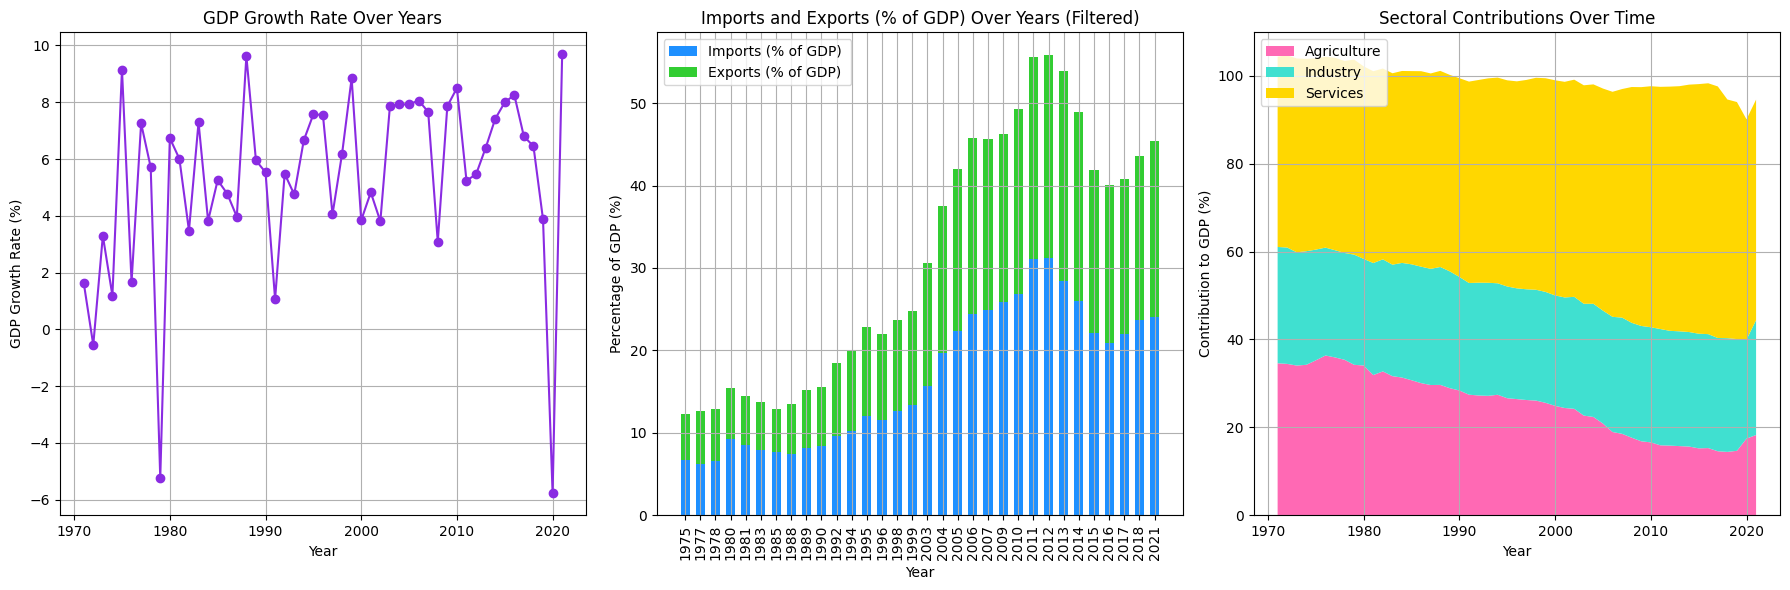

In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

gdp_growth_threshold = 5


df_filtered = df[df[' GDP growth (annual %) '] > gdp_growth_threshold]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].plot(df['Year'], df[' GDP growth (annual %) '], color='#8A2BE2', marker='o')
axs[0].set_title("GDP Growth Rate Over Years")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("GDP Growth Rate (%)")
axs[0].grid(True)

x = np.arange(len(df_filtered['Year']))
width = 0.6

axs[1].bar(x, df_filtered[' Imports  (% of GDP) '], width, label='Imports (% of GDP)', color='#1E90FF')
axs[1].bar(x, df_filtered['Exports (% of GDP) '], width, bottom=df_filtered[' Imports  (% of GDP) '], label='Exports (% of GDP) ', color='#32CD32')
axs[1].set_xticks(x)
axs[1].set_xticklabels(df_filtered['Year'].astype(int), rotation=90)
axs[1].set_title("Imports and Exports (% of GDP) Over Years (Filtered)")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Percentage of GDP (%)")
axs[1].legend()
axs[1].grid(True)

sector_colors = ['#FF69B4', '#40E0D0', '#FFD700']
axs[2].stackplot(df['Year'],
                 df['Agriculture Contribution (% of GDP)'],
                 df['Industry Contribution (% of GDP)'],
                 df['Services Contribution (% of GDP)'],
                 labels=['Agriculture', 'Industry', 'Services'],
                 colors=sector_colors)
axs[2].set_title("Sectoral Contributions Over Time")
axs[2].set_xlabel("Year")
axs[2].set_ylabel("Contribution to GDP (%)")
axs[2].legend(loc='upper left')
axs[2].grid(True)

plt.tight_layout()
plt.show()



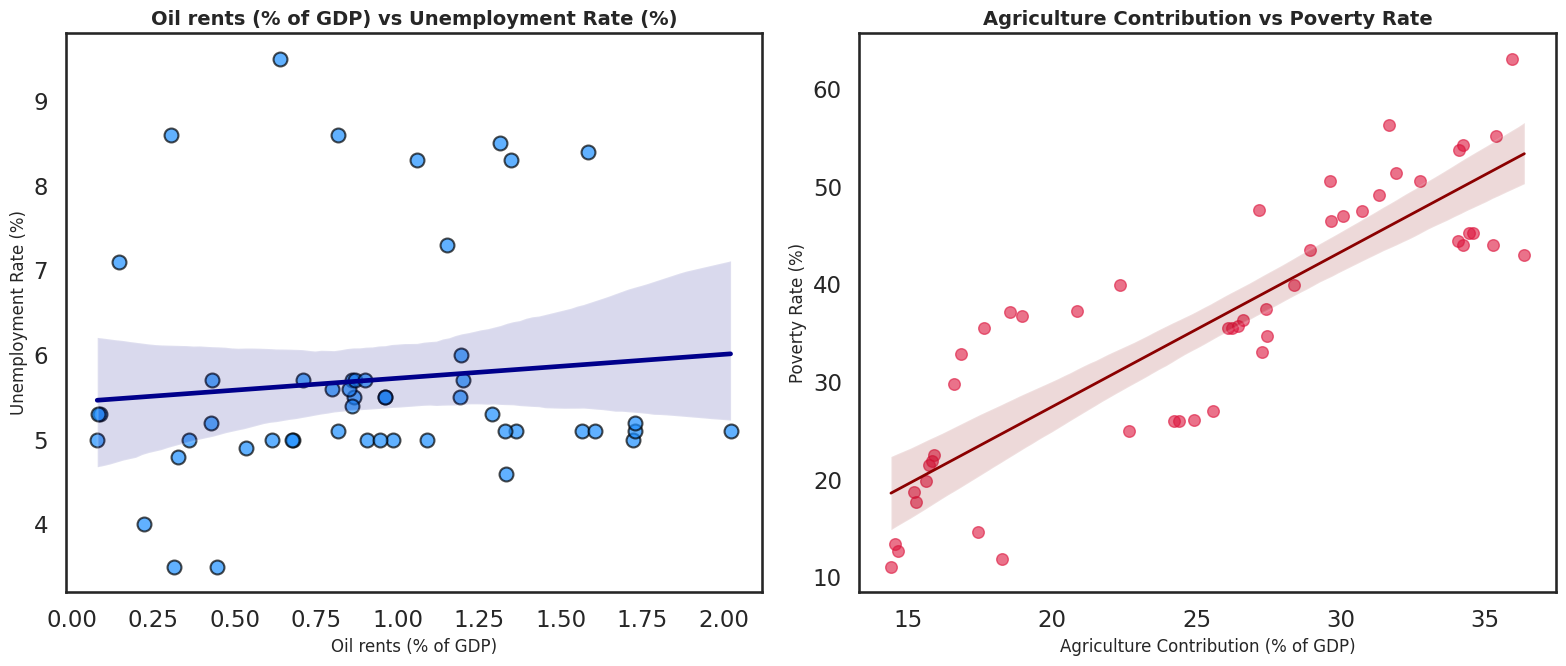

In [13]:

import seaborn as sns
# Configure seaborn aesthetics
sns.set_style('white')
sns.set_context('talk')
sns.set_palette('dark')

# Ensure numeric data and drop NaN values
df['Oil rents (% of GDP)'] = pd.to_numeric(df['Oil rents (% of GDP)'], errors='coerce')
df['Unemployment Rate (%)'] = pd.to_numeric(df['Unemployment Rate (%)'], errors='coerce')
df['Agriculture Contribution (% of GDP)'] = pd.to_numeric(df['Agriculture Contribution (% of GDP)'], errors='coerce')
df['Poverty Rate (%)'] = pd.to_numeric(df['Poverty Rate (%)'], errors='coerce')
df.dropna(
    subset=[
        'Oil rents (% of GDP)', 'Unemployment Rate (%)',
        'Agriculture Contribution (% of GDP)', 'Poverty Rate (%)'
    ],
    inplace=True
)

# Create a 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Oil rents vs Unemployment Rate
axes[0].scatter(
    df["Oil rents (% of GDP)"],
    df["Unemployment Rate (%)"],
    color='dodgerblue',
    edgecolor='black',
    s=100,
    alpha=0.7
)
sns.regplot(
    data=df,
    x="Oil rents (% of GDP)",
    y="Unemployment Rate (%)",
    ax=axes[0],
    scatter=False,
    color='darkblue'
)
axes[0].set_title("Oil rents (% of GDP) vs Unemployment Rate (%)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Oil rents (% of GDP)", fontsize=12)
axes[0].set_ylabel("Unemployment Rate (%)", fontsize=12)

# Plot 2: Agriculture Contribution vs Poverty Rate
sns.regplot(
    data=df,
    x="Agriculture Contribution (% of GDP)",
    y="Poverty Rate (%)",
    ax=axes[1],
    scatter_kws={'color': 'crimson', 's': 70, 'alpha': 0.6},
    line_kws={'color': 'darkred', 'lw': 2}
)
axes[1].set_title("Agriculture Contribution vs Poverty Rate", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Agriculture Contribution (% of GDP)", fontsize=12)
axes[1].set_ylabel("Poverty Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()


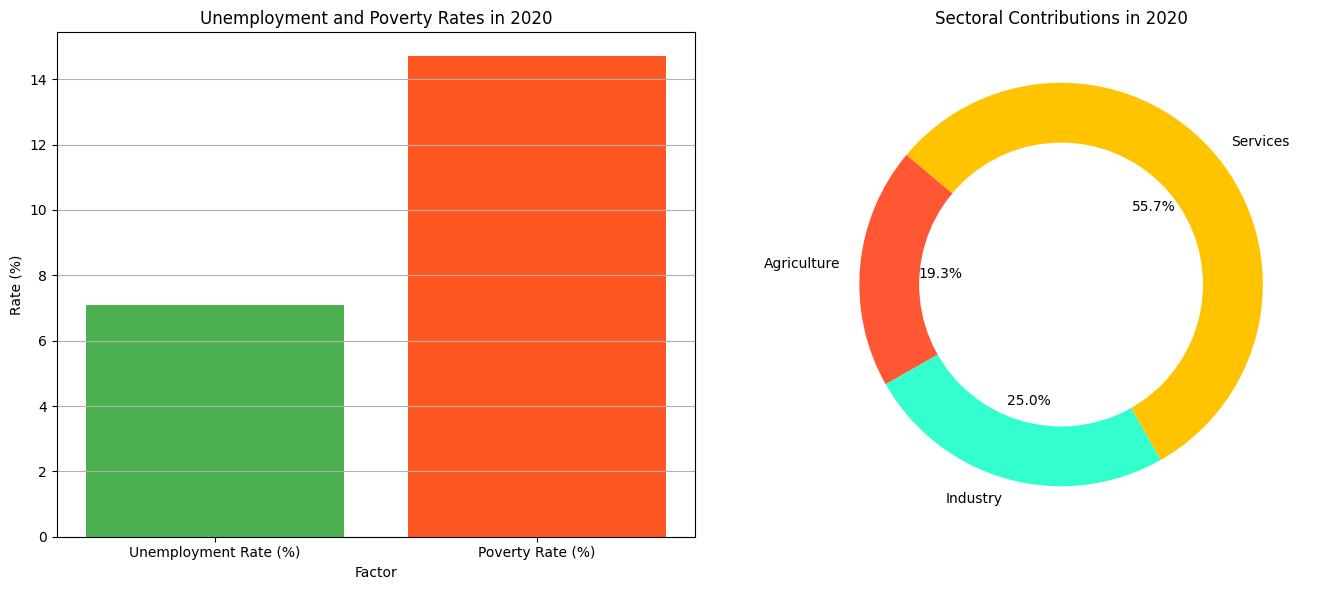

In [9]:
import matplotlib.pyplot as plt

sample_year = 2020

df_year = df[df['Year'] == sample_year]

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

factors = ['Unemployment Rate (%)', 'Poverty Rate (%)']
axs[0].bar(factors, df_year[factors].values[0], color=['#4CAF50', '#FF5722'])
axs[0].set_title(f"Unemployment and Poverty Rates in {sample_year}")
axs[0].set_xlabel("Factor")
axs[0].set_ylabel("Rate (%)")
axs[0].grid(axis='y')

sector_values = df_year[['Agriculture Contribution (% of GDP)', 'Industry Contribution (% of GDP)', 'Services Contribution (% of GDP)']].values[0]
sector_labels = ['Agriculture', 'Industry', 'Services']

colors = ['#FF5733', '#33FFCE', '#FFC300']

wedges, texts, autotexts = axs[1].pie(sector_values, labels=sector_labels, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops=dict(width=0.3))
axs[1].set_title(f"Sectoral Contributions in {sample_year}")
center_circle = plt.Circle((0, 0), 0.70, color='white')
axs[1].add_artist(center_circle)

plt.tight_layout()
plt.show()


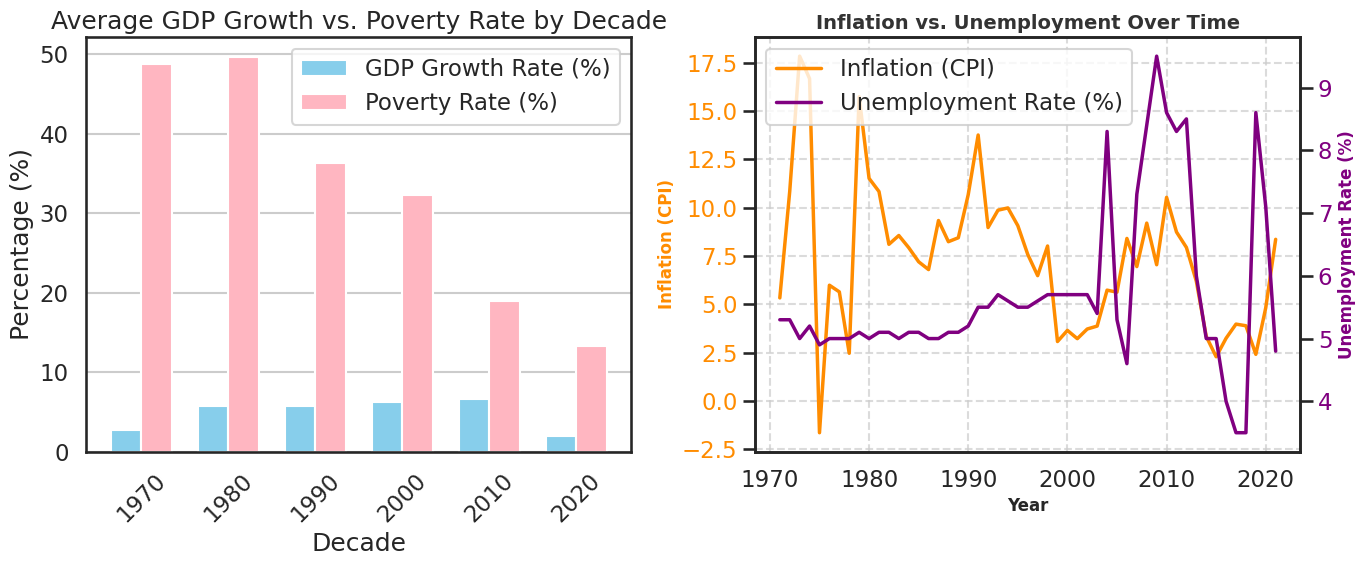

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming df is already defined and contains the relevant data
df['Decade'] = (df['Year'] // 10) * 10
df_decade = df.groupby('Decade').agg({' GDP growth (annual %) ': 'mean', 'Poverty Rate (%)': 'mean'})

# Create a 1x2 subplot grid
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Bar plot for GDP growth and Poverty Rate by Decade
x = np.arange(len(df_decade.index))
width = 0.35
axs[0].bar(x - width / 2, df_decade[' GDP growth (annual %) '], width, label='GDP Growth Rate (%)', color='#87CEEB')
axs[0].bar(x + width / 2, df_decade['Poverty Rate (%)'], width, label='Poverty Rate (%)', color='#FFB6C1')
axs[0].set_xticks(x)
axs[0].set_xticklabels(df_decade.index.astype(int), rotation=45)
axs[0].set_title("Average GDP Growth vs. Poverty Rate by Decade")
axs[0].set_xlabel("Decade")
axs[0].set_ylabel("Percentage (%)")
axs[0].legend()
axs[0].grid(True, axis='y')

# Chart 2: Line plot for Inflation and Unemployment Rate over time
ax2 = axs[1]
ax2.plot(df['Year'], df['Inflation CPI'], color='#FF8C00', linewidth=2.5, label="Inflation (CPI)")
ax2.set_ylabel("Inflation (CPI)", color='#FF8C00', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#FF8C00')
ax2.set_xlabel("Year", fontsize=12, fontweight='bold')
ax2.set_title("Inflation vs. Unemployment Over Time", fontsize=14, fontweight='bold', color='#333333')
ax2.grid(True, linestyle='--', alpha=0.7)

# Secondary y-axis for Unemployment Rate
ax2_secondary = ax2.twinx()
ax2_secondary.plot(df['Year'], df['Unemployment Rate (%)'], color='#800080', linewidth=2.5, linestyle='-', label="Unemployment Rate (%)")  # Purple color
ax2_secondary.set_ylabel("Unemployment Rate (%)", color='#800080', fontsize=12, fontweight='bold')
ax2_secondary.tick_params(axis='y', labelcolor='#800080')

# Combine legends
handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax2_secondary.get_legend_handles_labels()
lines = handles1 + handles2
labels = labels1 + labels2
ax2.legend(lines, labels, loc="upper left", frameon=True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()
